# A06 - Delivery Overprovisioning

## Objetivo
Analisar o fenômeno `delivered_pairs > requested_pairs` com dados reais e
já persistidos de todas as quatro campanhas (`C01`-`C04`): quão comum é,
sua relação com duração/memórias/estratégia, e por quê
`requested_pairs` não é um teto de entrega no SeQUeNCe (ver
`docs/metrics.md`). Este notebook **não roda nenhuma simulação**.

## Conceitos
- `requested_pairs` dimensiona o **pool de memórias reservado**
  (`RSVPProtocol.schedule`), não um limite de entregas: assim que uma
  memória entrega um par, ela é resetada para `RAW` e pode gerar
  entrelaçamento de novo, até `reservation.end_time`.
- `excess_delivery_pairs = max(0, delivered_pairs - requested_pairs)`;
  `delivery_ratio = delivered_pairs / requested_pairs` - ambos calculados
  uma vez, na persistência do trial, nunca truncados depois.


## Configuração


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from ibqn.experiments.persistence import read_trials_dataframe, trials_csv_path
from ibqn.experiments.export import save_figure, save_table

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures" / "article"
TABLES_DIR = RESULTS_DIR / "tables" / "article"
CAMPAIGNS = ["C01_routing_strategy", "C02_fidelity_throughput", "C03_assurance_outcomes", "C04_reconciliation_effectiveness"]

all_trials_df = pd.concat(
    [read_trials_dataframe(trials_csv_path(RESULTS_DIR, c)).assign(campaign_name=c) for c in CAMPAIGNS],
    ignore_index=True,
)
delivered_df = all_trials_df[all_trials_df["delivered_pairs"].notna()].copy()
delivered_df[["campaign_name", "routing_strategy", "purification_policy", "duration_s", "requested_pairs", "delivered_pairs", "excess_delivery_pairs", "delivery_ratio"]]


,campaign_name,routing_strategy,purification_policy,duration_s,requested_pairs,delivered_pairs,excess_delivery_pairs,delivery_ratio
0,C01_routing_strategy,shortest_hop_count,automatic,0.10,10,4.0,0.0,0.4
1,C01_routing_strategy,shortest_hop_count,automatic,0.10,10,5.0,0.0,0.5
2,C01_routing_strategy,shortest_hop_count,automatic,0.10,10,4.0,0.0,0.4
3,C01_routing_strategy,least_loss,automatic,0.10,10,444.0,434.0,44.4
4,C01_routing_strategy,least_loss,automatic,0.10,10,450.0,440.0,45.0
5,C01_routing_strategy,least_loss,automatic,0.10,10,445.0,435.0,44.5
6,C01_routing_strategy,highest_fidelity,automatic,0.10,10,4.0,0.0,0.4
7,C01_routing_strategy,highest_fidelity,automatic,0.10,10,5.0,0.0,0.5
8,C01_routing_strategy,highest_fidelity,automatic,0.10,10,4.0,0.0,0.4
9,C02_fidelity_throughput,shortest_hop_count,disabled,0.05,10,237.0,227.0,23.7


## Execução


In [2]:
print(f"n = {len(delivered_df)} trials with delivery evidence")
print(f"trials with delivered_pairs > requested_pairs: {(delivered_df['excess_delivery_pairs'] > 0).sum()} / {len(delivered_df)}")
print(f"delivery_ratio: min={delivered_df['delivery_ratio'].min():.2f}, median={delivered_df['delivery_ratio'].median():.2f}, max={delivered_df['delivery_ratio'].max():.2f}")


n = 27 trials with delivery evidence
trials with delivered_pairs > requested_pairs: 16 / 27
delivery_ratio: min=0.10, median=5.80, max=45.70


## Resultados


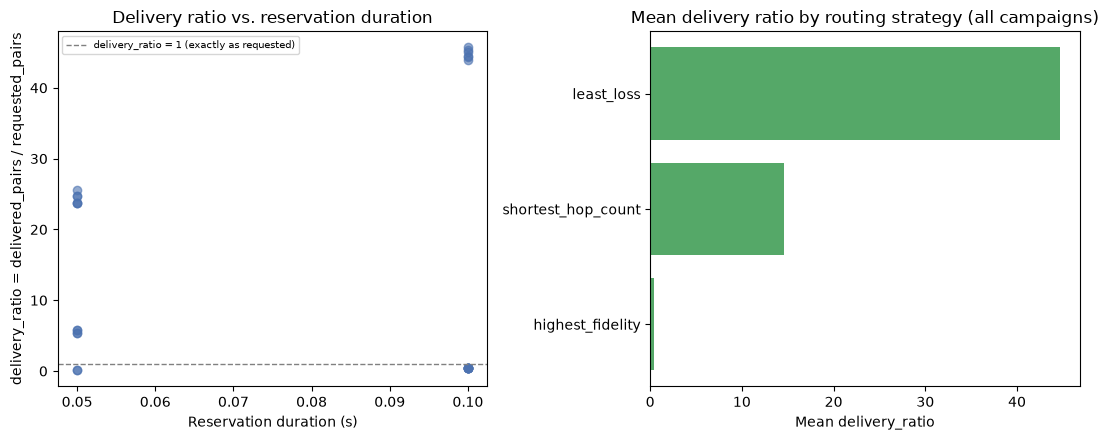

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(delivered_df["duration_s"], delivered_df["delivery_ratio"], alpha=0.6, c="#4C72B0")
axes[0].set_xlabel("Reservation duration (s)")
axes[0].set_ylabel("delivery_ratio = delivered_pairs / requested_pairs")
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="delivery_ratio = 1 (exactly as requested)")
axes[0].set_title("Delivery ratio vs. reservation duration")
axes[0].legend(fontsize=7)

by_strategy = delivered_df.groupby("routing_strategy")["delivery_ratio"].mean().sort_values()
axes[1].barh(by_strategy.index.astype(str), by_strategy.values, color="#55A868")
axes[1].set_xlabel("Mean delivery_ratio")
axes[1].set_title("Mean delivery ratio by routing strategy (all campaigns)")

fig.tight_layout()
save_figure(fig, "A06_delivery_overprovisioning", directory=FIGURES_DIR)
plt.show()


In [4]:
by_purification = delivered_df[delivered_df["purification_policy"].notna()].groupby("purification_policy")["delivery_ratio"].agg(["count", "mean", "median"])
save_table(by_purification.reset_index(), "A06_delivery_ratio_by_purification", directory=TABLES_DIR)
by_purification


,count,mean,median
purification_policy,,,
automatic,25,15.724,5.4
disabled,2,24.200,24.2


In [5]:
extreme_case = delivered_df.loc[delivered_df["delivery_ratio"].idxmax()]
print(f"Largest overprovisioning observed: campaign={extreme_case['campaign_name']}, strategy={extreme_case['routing_strategy']}, "
      f"requested={extreme_case['requested_pairs']:.0f}, delivered={extreme_case['delivered_pairs']:.0f}, "
      f"delivery_ratio={extreme_case['delivery_ratio']:.1f}x")


Largest overprovisioning observed: campaign=C04_reconciliation_effectiveness, strategy=shortest_hop_count, requested=10, delivered=457, delivery_ratio=45.7x


In [6]:
assert (delivered_df["delivered_pairs"] >= 0).all()
assert (delivered_df["excess_delivery_pairs"] == (delivered_df["delivered_pairs"] - delivered_df["requested_pairs"]).clip(lower=0)).all()
assert (delivered_df["delivery_ratio"] > 1).any(), "overprovisioning must actually occur somewhere in this dataset"
print(f"Confirmed: {(delivered_df['delivery_ratio'] > 1).sum()} / {len(delivered_df)} trials delivered more pairs than requested.")


Confirmed: 16 / 27 trials delivered more pairs than requested.


## Interpretação
A maioria dos trials com uma rota de baixa perda (`least_loss` no diamante,
ou o cenário `three_node` sem purificação) entrega dezenas a centenas de
vezes mais pares que o pedido, porque a janela de reserva
(`duration_s`) é o fator que realmente limita a entrega, não
`requested_pairs`. Purificação reduz sistematicamente o `delivery_ratio`
médio (cada par purificado consome mais recursos brutos por par final
entregue - notebook 17 da Fase H2), mas não o elimina. Isso confirma
quantitativamente, com dados de campanha, o que já era conhecido
qualitativamente desde o notebook 01 da Fase H1.

## Limitações
- As quatro campanhas não foram desenhadas para variar sistematicamente
  `duration_s` sozinho (mantendo tudo mais fixo) - a relação
  duração-vs-overprovisioning aqui é observacional, não um sweep
  controlado dedicado a essa pergunta.
- `delivery_ratio` não é penalizado nem recompensado por nenhuma condição
  de sucesso desta arquitetura - é puramente informativo.

## Conclusão
`requested_pairs` confirmado, com dados reais de campanha, como um
dimensionamento de pool de memórias - não um teto de entrega; o quanto se
excede depende principalmente da janela de tempo e da rota/estratégia,
não de nenhum limite deliberado do requisito declarado.
